## Task 1: Exploring and Visualizing a Simple Dataset


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
#Data Shape
df=sns.load_dataset('iris')
print("Dataset Loaded")
print(f"Shape: {df.shape}")

Dataset Loaded
Shape: (150, 5)


In [6]:
#Columns Name
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [7]:
#Info
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [8]:
#Summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
#Count of classes
print("Species value counts:")
print(df['species'].value_counts())

Species value counts:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Plots


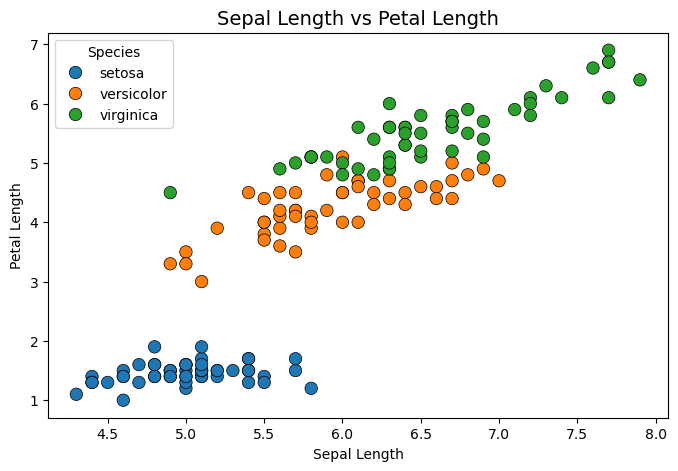

In [10]:
#Scatter Plot
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='sepal_length',
    y='petal_length',
    hue='species',
    s=80,
    edgecolor='black',
    linewidth=0.5
)
plt.title('Sepal Length vs Petal Length', fontsize=14)
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.legend(title='Species')
plt.show()

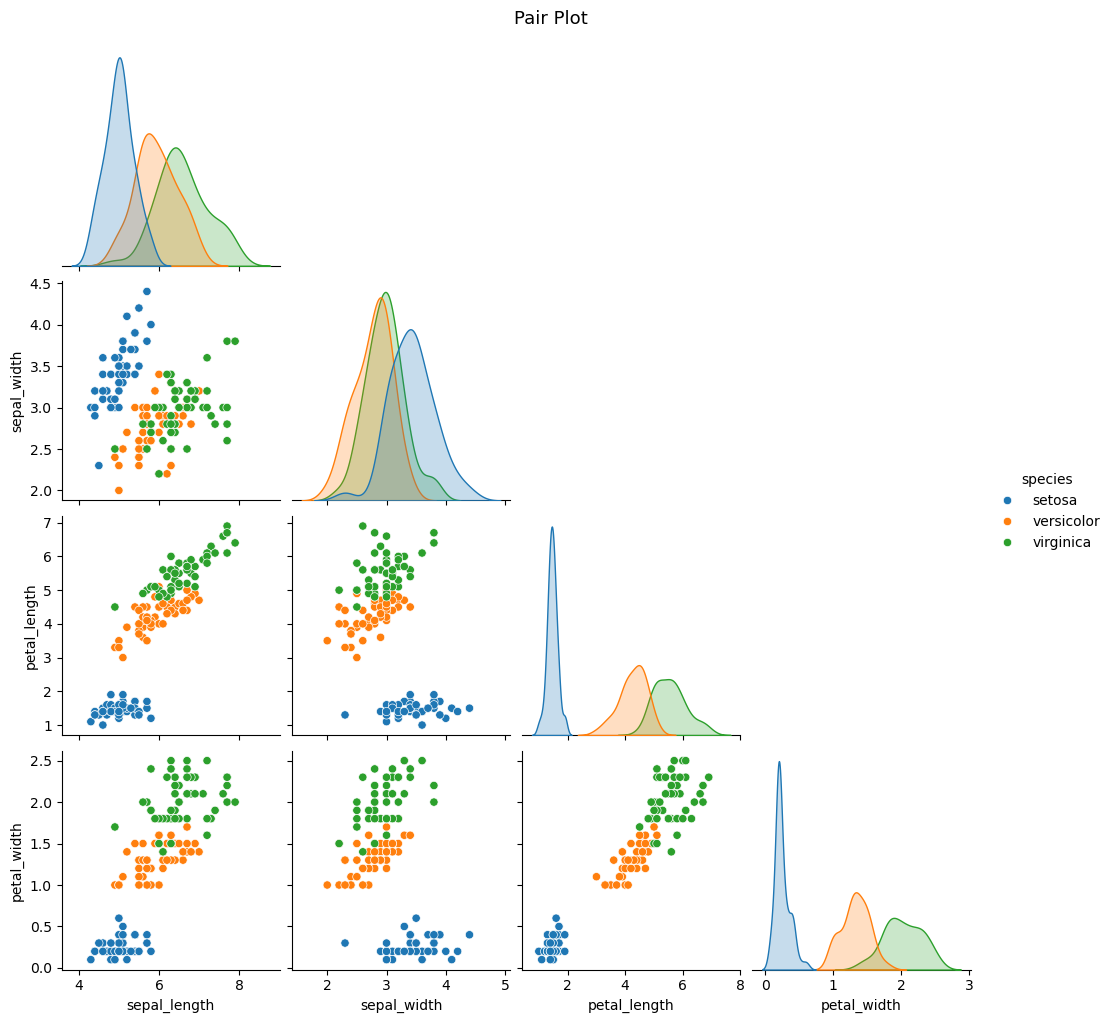

In [11]:
#Pair Plot
sns.pairplot(df,hue='species',corner=True)
plt.suptitle('Pair Plot',y=1.02,fontsize=13)
plt.show()

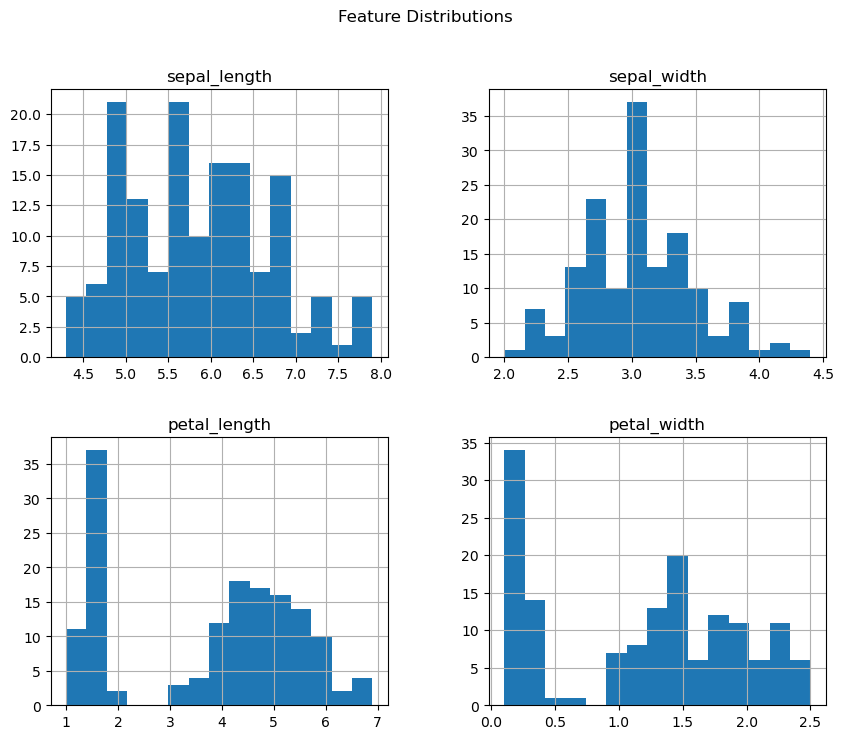

In [12]:
#Histogram
features=['sepal_length','sepal_width','petal_length','petal_width']
df[features].hist(figsize=(10,8),bins=15)
plt.suptitle('Feature Distributions')
plt.show()


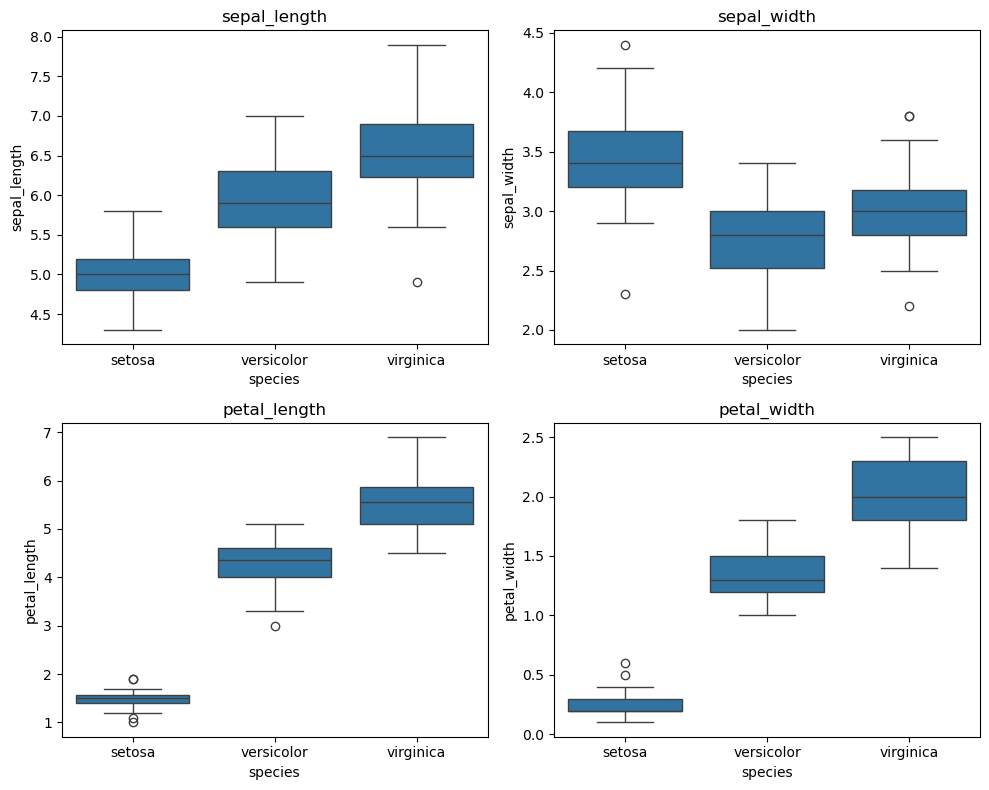

In [18]:
#Box Plot
fig,axes=plt.subplots(2,2,figsize=(10,8))
for ax,feature in zip(axes.flatten(),features):
    sns.boxplot(x='species',y=feature,data=df,ax=ax)
    ax.set_title(feature)
plt.tight_layout()
plt.show()



## Conclusion
1. This dataset has 150 samples with 3 species.
2. Setosa is clearly separable from other species.
3. Versicolor and virgincia overlap slightly.
4. Petal features are most discriminative, they show greatest differnce.
5. Seaborn's pairplot reveals that petal length * petal width is best 2D feature.

## Task 2: Credit Risk Prediction


In [13]:
import numpy as np

In [15]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
#Load Dataset
df=pd.read_csv('loan_prediction.csv')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (367, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [17]:
#Data Inspection
print("Columns: ", df.columns.tolist())
print("\nShape:", df.shape)
df.info()

Columns:  ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']

Shape: (367, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: f

In [18]:
#Missing values
missing=df.isnull().sum()
missing_pct=(missing/len(df))*100
print("Missing values:")
print(pd.DataFrame({'Count':missing,'Percentage':missing_pct})[missing>0])

Missing values:
                  Count  Percentage
Gender               11    2.997275
Dependents           10    2.724796
Self_Employed        23    6.267030
LoanAmount            5    1.362398
Loan_Amount_Term      6    1.634877
Credit_History       29    7.901907


In [19]:
#Handle missing data
for col in ['Gender','Married','Dependents','Self_Employed','Credit_History']:
    df[col].fillna(df[col].mode()[0],inplace=True)

df['LoanAmount'].fillna(df['LoanAmount'].median(),inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0],inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum().sum(),"\nAll Handled")

Missing values after cleaning:
0 
All Handled


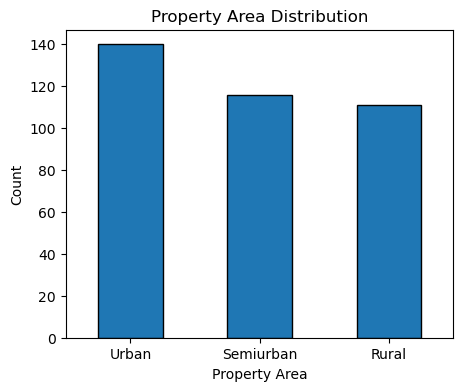

In [20]:
#EDA
plt.figure(figsize=(5,4))
df['Property_Area'].value_counts().plot( kind='bar', edgecolor='black', rot=0)

plt.title('Property Area Distribution')
plt.xlabel('Property Area')
plt.ylabel('Count')

plt.show()

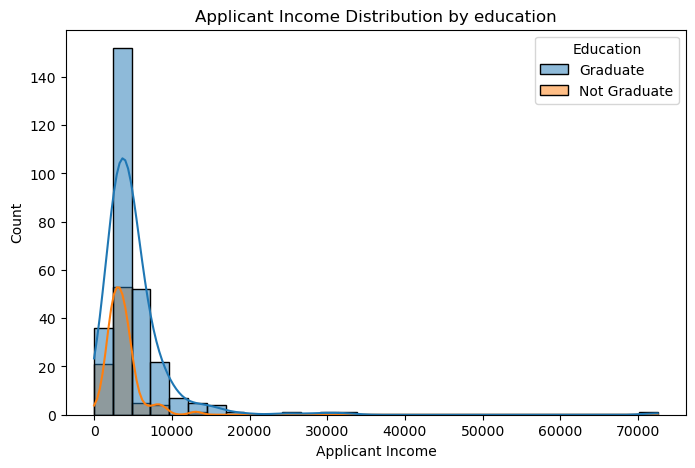

In [21]:
#EDA
plt.figure(figsize=(8,5))
sns.histplot( data=df, x='ApplicantIncome', hue='Education', bins=30, kde=True)

plt.title('Applicant Income Distribution by education')
plt.xlabel('Applicant Income')

plt.show()

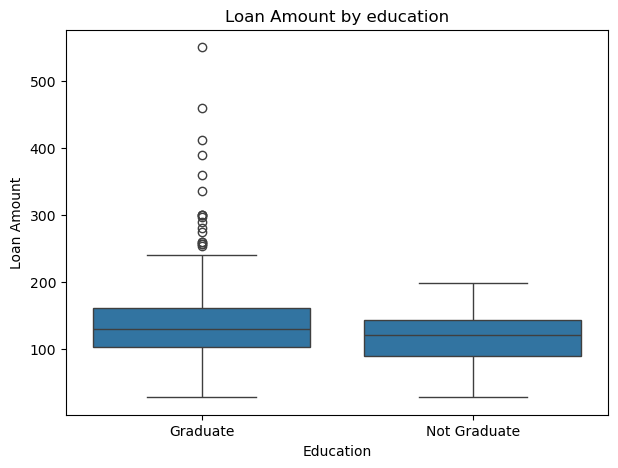

In [22]:
#EDA
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Education', y='LoanAmount')

plt.title('Loan Amount by education')
plt.xlabel('Education')
plt.ylabel('Loan Amount')

plt.show()

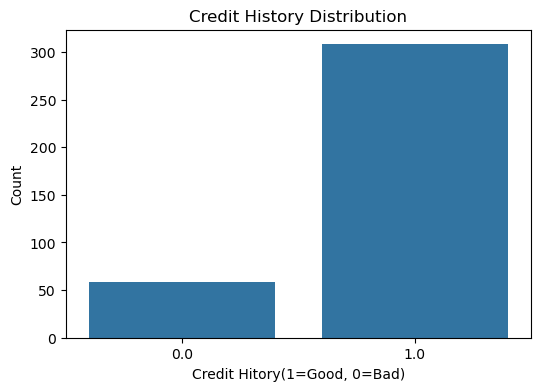

In [23]:
#EDA
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Credit_History')

plt.title('Credit History Distribution')
plt.xlabel('Credit Hitory(1=Good, 0=Bad)')
plt.ylabel('Count')

plt.show()

In [24]:
#data processing for modeling
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
cat_cols=df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    df[col]=le.fit_transform(df[col])

print("All Categorical columns encoded")
print("Sample:")
df.head(3)

All Categorical columns encoded
Sample:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,0,1,1,0,0,0,5720,0,110.0,360.0,1.0,2
1,1,1,1,1,0,0,3076,1500,126.0,360.0,1.0,2
2,2,1,1,2,0,0,5000,1800,208.0,360.0,1.0,2


In [25]:
#Define X and y
from sklearn.model_selection import train_test_split
X=df.drop('Credit_History',axis=1)
y=df['Credit_History']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(f"Train Size:{X_train.shape[0]}")
print(f"Test Size:{X_test.shape[0]}")

Train Size:293
Test Size:74


In [26]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
lr_model=LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train,y_train)
lr_pred=lr_model.predict(X_test)

print("Logistic Regression")
print(f"Accuracy:{accuracy_score(y_test,lr_pred)}")
print("\nClassification Report: ")
print(classification_report(y_test, lr_pred))

Logistic Regression
Accuracy:0.7432432432432432

Classification Report: 
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        19
         1.0       0.74      1.00      0.85        55

    accuracy                           0.74        74
   macro avg       0.37      0.50      0.43        74
weighted avg       0.55      0.74      0.63        74



In [27]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt_model=DecisionTreeClassifier(max_depth=5,random_state=42)
dt_model.fit(X_train,y_train)
dt_pred=dt_model.predict(X_test)

print("Decision Tree")
print(f"Accuracy:{accuracy_score(y_test, dt_pred)}")
print("\nClassification Report: ")
print(classification_report(y_test, dt_pred))

Decision Tree
Accuracy:0.6891891891891891

Classification Report: 
              precision    recall  f1-score   support

         0.0       0.33      0.21      0.26        19
         1.0       0.76      0.85      0.80        55

    accuracy                           0.69        74
   macro avg       0.55      0.53      0.53        74
weighted avg       0.65      0.69      0.66        74



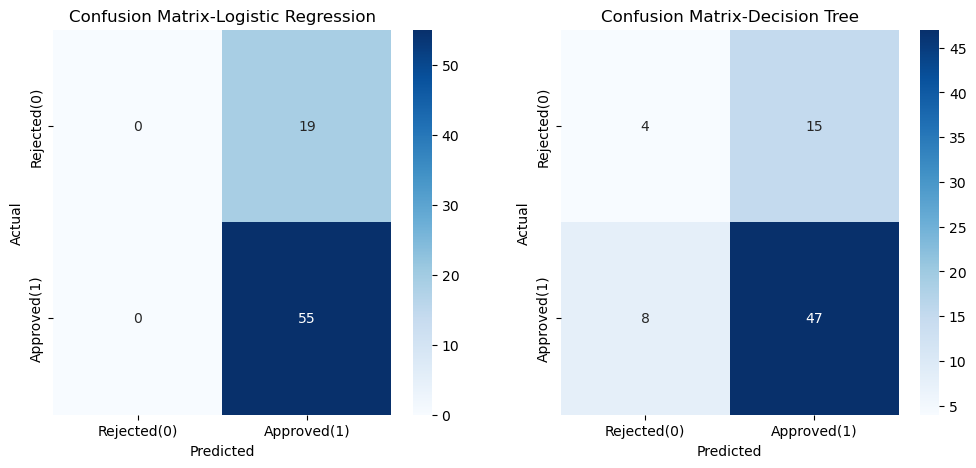

In [28]:
#Evaluation
fig, axes=plt.subplots(1,2, figsize=(12,5))

for ax, pred, title in zip(axes, [lr_pred,dt_pred],['Logistic Regression','Decision Tree']):
    cm=confusion_matrix(y_test,pred)
    sns.heatmap(cm, annot=True,fmt='d',cmap='Blues',ax=ax,
                xticklabels=['Rejected(0)','Approved(1)'], yticklabels=['Rejected(0)','Approved(1)'])
    ax.set_title(f'Confusion Matrix-{title}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.show()

## Conclusion
1. Logistic Regression and Decision Tree were both trained to predict loan default.
2. Credit History is the most important predictor.
3. Missing values were handled by mode/median.
4. The models achieved reasonable accuracy. Decision Tree may slightly overfit without pruning.


## Task 3: Customer Churn Prediction (Bank Customers)

In [29]:
# Load Dataset
df=pd.read_csv('Churn_Modelling.csv')

print(f"Dataset shape:{df.shape}")
df.head()

Dataset shape:(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [30]:
#Data Inspection
print("Shape:",df.shape)
print("\nColumns:",df.columns.tolist())
print("\nMissing Values:\n",df.isnull().sum())
print("\nChurn Distribution:")
print(df['Exited'].value_counts())
print(f"Churn rate:{df['Exited'].mean()*100}%")

Shape: (10000, 14)

Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Missing Values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Churn Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64
Churn rate:20.369999999999997%


In [31]:
#Clean Data
df.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

print("Dropped identifier columns")
print("Remaining features:", df.columns.tolist())

Dropped identifier columns
Remaining features: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [32]:
#Label Encoding
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
print("Gender Encoded:",dict(zip(le.classes_,le.transform(le.classes_))))

df=pd.get_dummies(df,columns=['Geography'],drop_first=True)
print("One-hot encoded Geogrpahy. New Columns:",[c for c in df.columns if 'Geography' in c])

df.head(3)

Gender Encoded: {'Female': np.int64(0), 'Male': np.int64(1)}
One-hot encoded Geogrpahy. New Columns: ['Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False


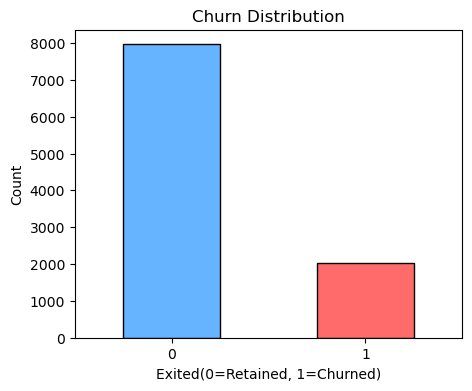

In [33]:
#EDA
plt.figure(figsize=(5,4))
df['Exited'].value_counts().plot(kind='bar',color=['#66b3ff', '#ff6b6b'],edgecolor='black',rot=0)
plt.title('Churn Distribution')
plt.xlabel('Exited(0=Retained, 1=Churned)')
plt.ylabel('Count')
plt.show()

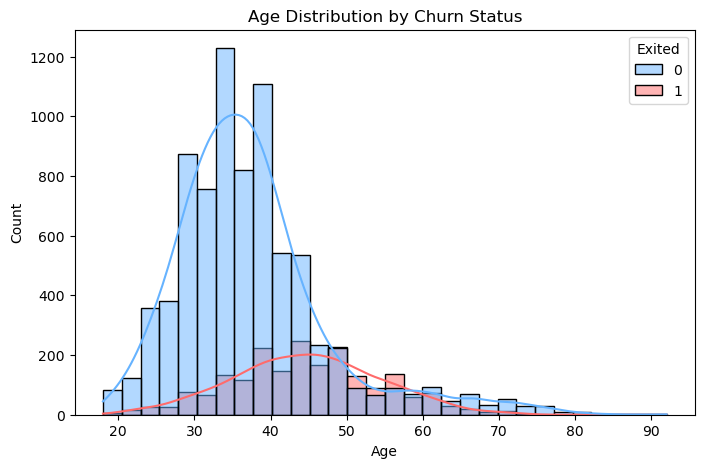

In [34]:
#EDA
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='Age',hue='Exited',bins=30,kde=True,palette={0:'#66b3ff',1:'#ff6b6b'})
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.show()

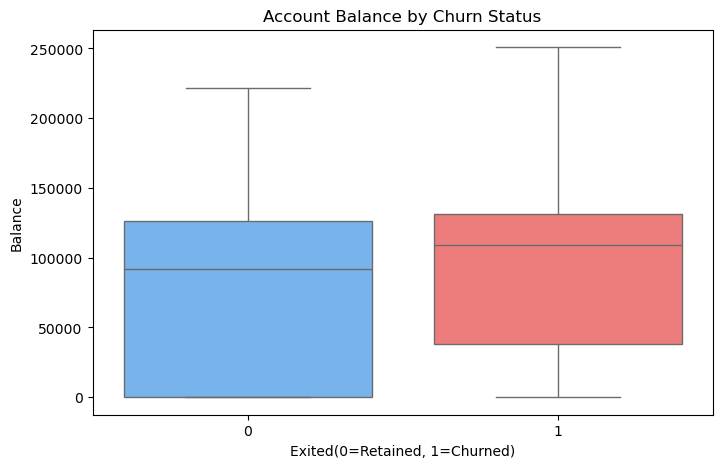

In [35]:
#EDA
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='Exited',y='Balance', palette={'0':'#66b3ff','1':'#ff6b6b'})
plt.title('Account Balance by Churn Status')
plt.xlabel('Exited(0=Retained, 1=Churned)')
plt.ylabel('Balance')
plt.show()

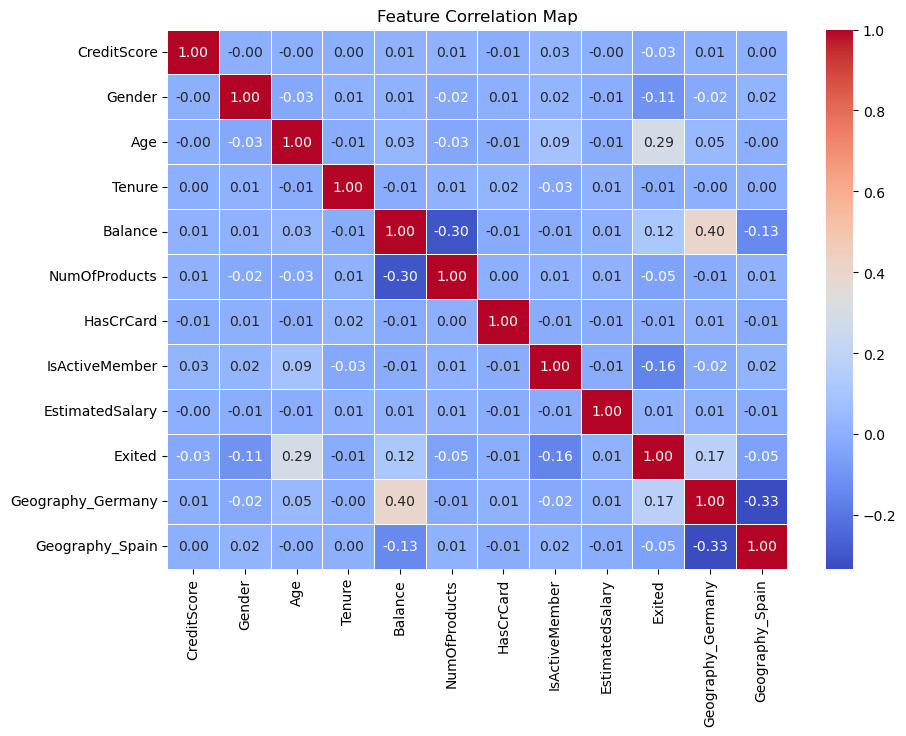

In [37]:
#EDA
plt.figure(figsize=(10, 7))
corr=df.corr()
sns.heatmap(corr,annot=True ,fmt='.2f',cmap='coolwarm',linewidth=0.5)
plt.title('Feature Correlation Map')
plt.show()

In [39]:
#define X and y
from sklearn.preprocessing import LabelEncoder, StandardScaler

X=df.drop('Exited',axis=1)
y=df['Exited']

#Scale Features
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42,stratify=y)
print(f"Train: {X_train.shape[0]} | Test:{X_test.shape[0]}")


Train: 8000 | Test:2000


In [41]:
#Train Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
models={
    'Logistic Regression':LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':RandomForestClassifier(n_estimators=100,random_state=42),
    'Gradient Boosting':GradientBoostingClassifier(n_estimators=100,random_state=42)
}

results={}
for name, model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    acc=accuracy_score(y_test,pred)
    results[name]={'model':model,'pred':pred,'accuracy':acc}
    print(f"{name}:Accuracy={acc}")

Logistic Regression:Accuracy=0.808
Random Forest:Accuracy=0.861
Gradient Boosting:Accuracy=0.87


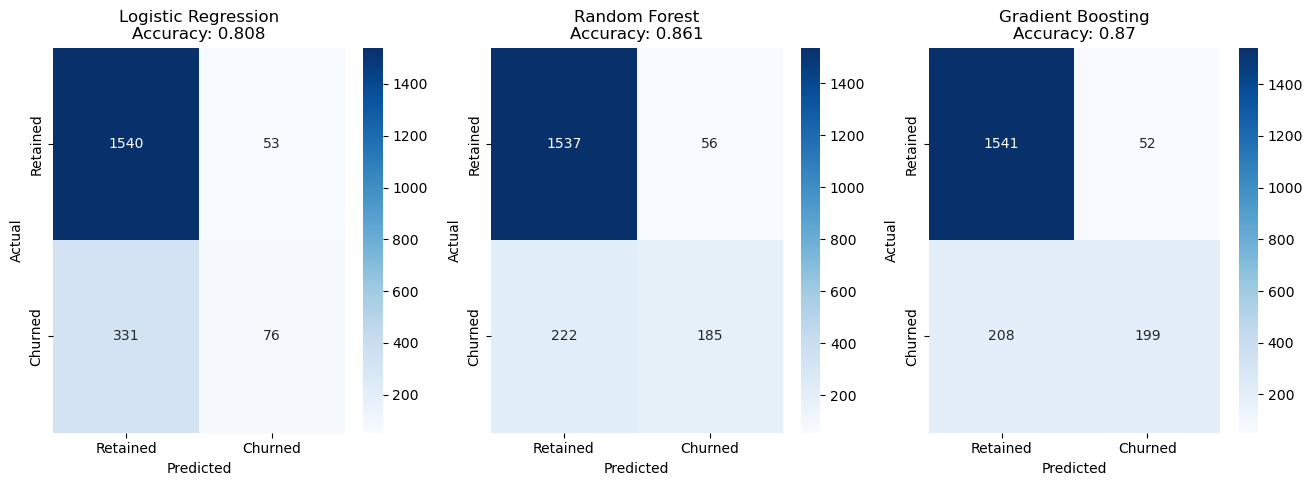

In [42]:
#Evaluation
fig,axes=plt.subplots(1,3,figsize=(16,5))

for ax, (name,res) in zip(axes,results.items()):
    cm=confusion_matrix(y_test,res['pred'])
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax, xticklabels=['Retained','Churned'], yticklabels=['Retained','Churned'])
    ax.set_title(f"{name}\nAccuracy: {res['accuracy']}")
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.show()


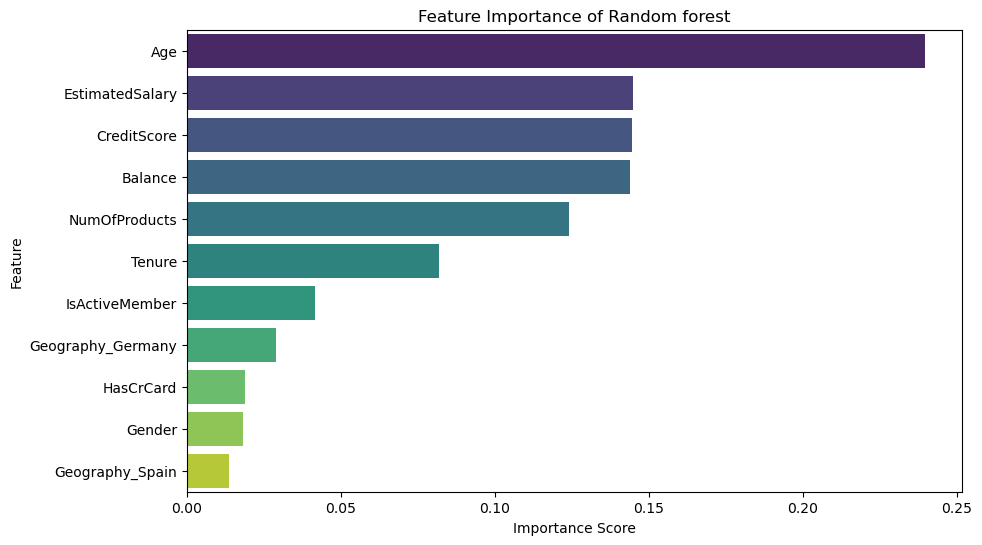

Top 5 features influencing churn:
        Feature  Importance
            Age    0.239730
EstimatedSalary    0.144951
    CreditScore    0.144612
        Balance    0.143798
  NumOfProducts    0.123917


In [46]:
#Feature Importance

rf_model=results['Random Forest']['model']
feature_names=df.drop('Exited',axis=1).columns.tolist()

importance_df=pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance',ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df,x='Importance',y='Feature',palette='viridis')
plt.title('Feature Importance of Random forest')
plt.xlabel('Importance Score')
plt.show()

print("Top 5 features influencing churn:")
print(importance_df.head(5).to_string(index=False))

## Conclusion
1. Random Forest and Gradient Boosting outperform Logistic Regression on this dataset.
2. The most important churn predictors are Age,Balance,NumofProducts and isactivememeber.
3. Customers aged 40-60 with high balances ae morer likely to churn.
4. Inactive members have a significantly higherr churn rate.